# Benchmarking (Práctica)

In [39]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, root_mean_squared_error

**1. Carga y Exploración de Datos**

In [40]:
boston = fetch_openml(name='boston', version=1, as_frame=True)
df = boston.frame


In [41]:
print("Primeras filas del DataFrame:")
display(df.head(10))

print("Ultimas filas del DataFrame:")
print(df.tail(5))

print("Informacion del DataFrame:")
print(df.info())

print("Dimension del DataFrame:")
print(df.shape)

Primeras filas del DataFrame:


,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242.0,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222.0,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222.0,18.7,396.90,5.33,36.2
5,0.02985,0.0,2.18,0,0.458,6.430,58.7,6.0622,3,222.0,18.7,394.12,5.21,28.7
6,0.08829,12.5,7.87,0,0.524,6.012,66.6,5.5605,5,311.0,15.2,395.60,12.43,22.9
7,0.14455,12.5,7.87,0,0.524,6.172,96.1,5.9505,5,311.0,15.2,396.90,19.15,27.1
8,0.21124,12.5,7.87,0,0.524,5.631,100.0,6.0821,5,311.0,15.2,386.63,29.93,16.5
9,0.17004,12.5,7.87,0,0.524,6.004,85.9,6.5921,5,311.0,15.2,386.71,17.10,18.9


Ultimas filas del DataFrame:
        CRIM   ZN  INDUS CHAS    NOX     RM   AGE     DIS RAD    TAX  PTRATIO  \
501  0.06263  0.0  11.93    0  0.573  6.593  69.1  2.4786   1  273.0     21.0   
502  0.04527  0.0  11.93    0  0.573  6.120  76.7  2.2875   1  273.0     21.0   
503  0.06076  0.0  11.93    0  0.573  6.976  91.0  2.1675   1  273.0     21.0   
504  0.10959  0.0  11.93    0  0.573  6.794  89.3  2.3889   1  273.0     21.0   
505  0.04741  0.0  11.93    0  0.573  6.030  80.8  2.5050   1  273.0     21.0   

          B  LSTAT  MEDV  
501  391.99   9.67  22.4  
502  396.90   9.08  20.6  
503  396.90   5.64  23.9  
504  393.45   6.48  22.0  
505  396.90   7.88  11.9  
Informacion del DataFrame:
<class 'pandas.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype   
---  ------   --------------  -----   
 0   CRIM     506 non-null    float64 
 1   ZN       506 non-null    float64 
 2   INDUS    506 non-null    float64 
 3   C

In [42]:
print("Estadisticas descriptivas del DataFrame:")
print(df.describe())

Estadisticas descriptivas del DataFrame:
             CRIM          ZN       INDUS         NOX          RM         AGE  \
count  506.000000  506.000000  506.000000  506.000000  506.000000  506.000000   
mean     3.613524   11.363636   11.136779    0.554695    6.284634   68.574901   
std      8.601545   23.322453    6.860353    0.115878    0.702617   28.148861   
min      0.006320    0.000000    0.460000    0.385000    3.561000    2.900000   
25%      0.082045    0.000000    5.190000    0.449000    5.885500   45.025000   
50%      0.256510    0.000000    9.690000    0.538000    6.208500   77.500000   
75%      3.677083   12.500000   18.100000    0.624000    6.623500   94.075000   
max     88.976200  100.000000   27.740000    0.871000    8.780000  100.000000   

              DIS         TAX     PTRATIO           B       LSTAT        MEDV  
count  506.000000  506.000000  506.000000  506.000000  506.000000  506.000000  
mean     3.795043  408.237154   18.455534  356.674032   12.653063   2

In [43]:
print("Tipos originales:")
print(df.dtypes)

Tipos originales:
CRIM        float64
ZN          float64
INDUS       float64
CHAS       category
NOX         float64
RM          float64
AGE         float64
DIS         float64
RAD        category
TAX         float64
PTRATIO     float64
B           float64
LSTAT       float64
MEDV        float64
dtype: object


In [44]:
n_duplicados = df.duplicated().sum()
print(f"Filas duplicadas: {n_duplicados}")

Filas duplicadas: 0


In [45]:
print("Verificacion de datos nulos:")
print(df.isnull().sum())

Verificacion de datos nulos:
CRIM       0
ZN         0
INDUS      0
CHAS       0
NOX        0
RM         0
AGE        0
DIS        0
RAD        0
TAX        0
PTRATIO    0
B          0
LSTAT      0
MEDV       0
dtype: int64


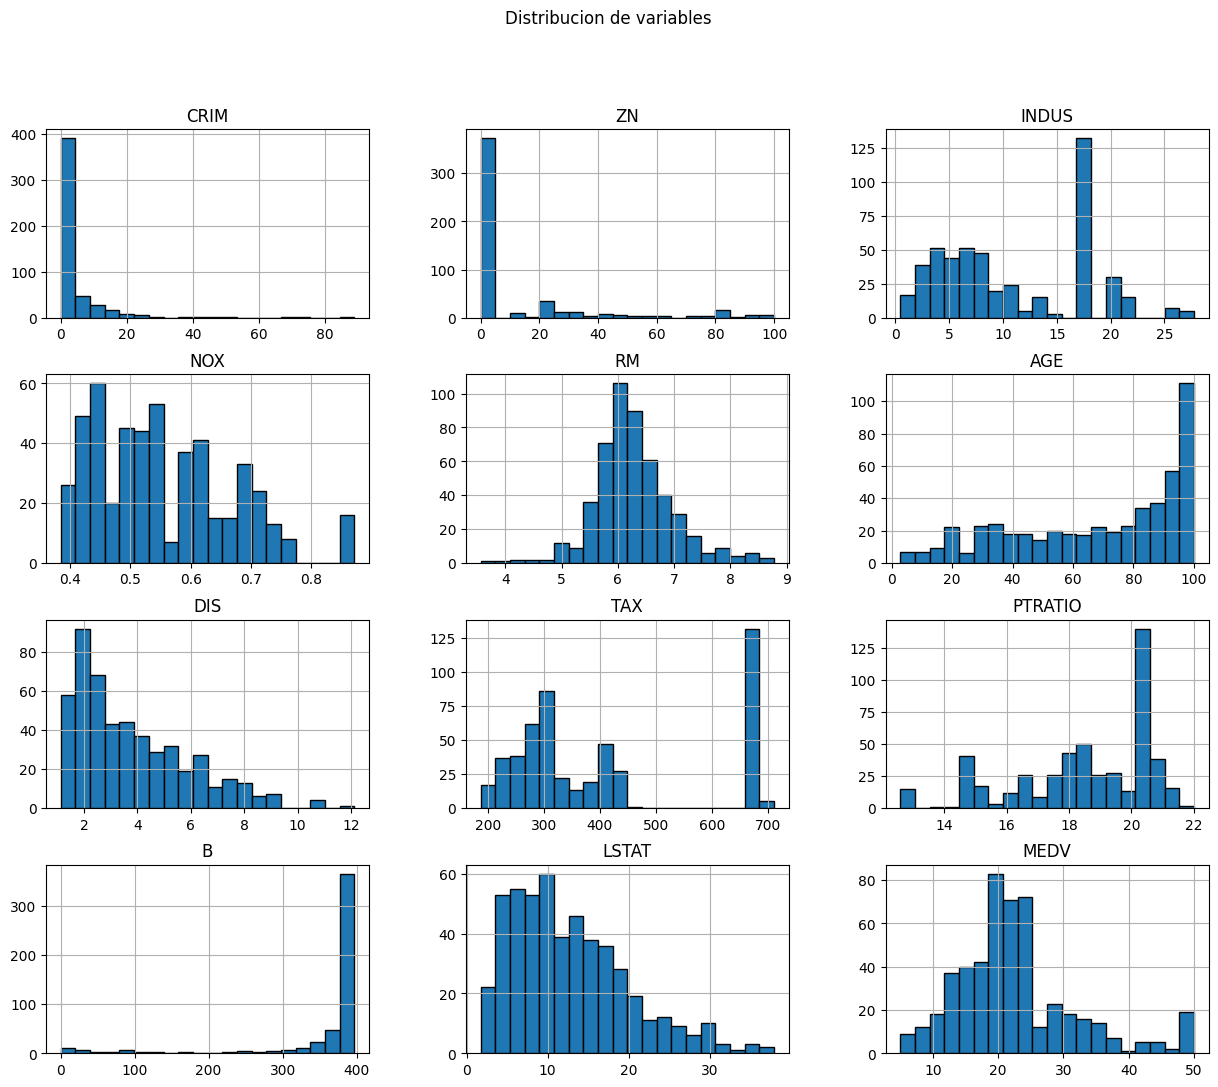

In [46]:
df.hist(figsize=(15,12), bins=20, edgecolor='black')
plt.suptitle('Distribucion de variables')
plt.show()

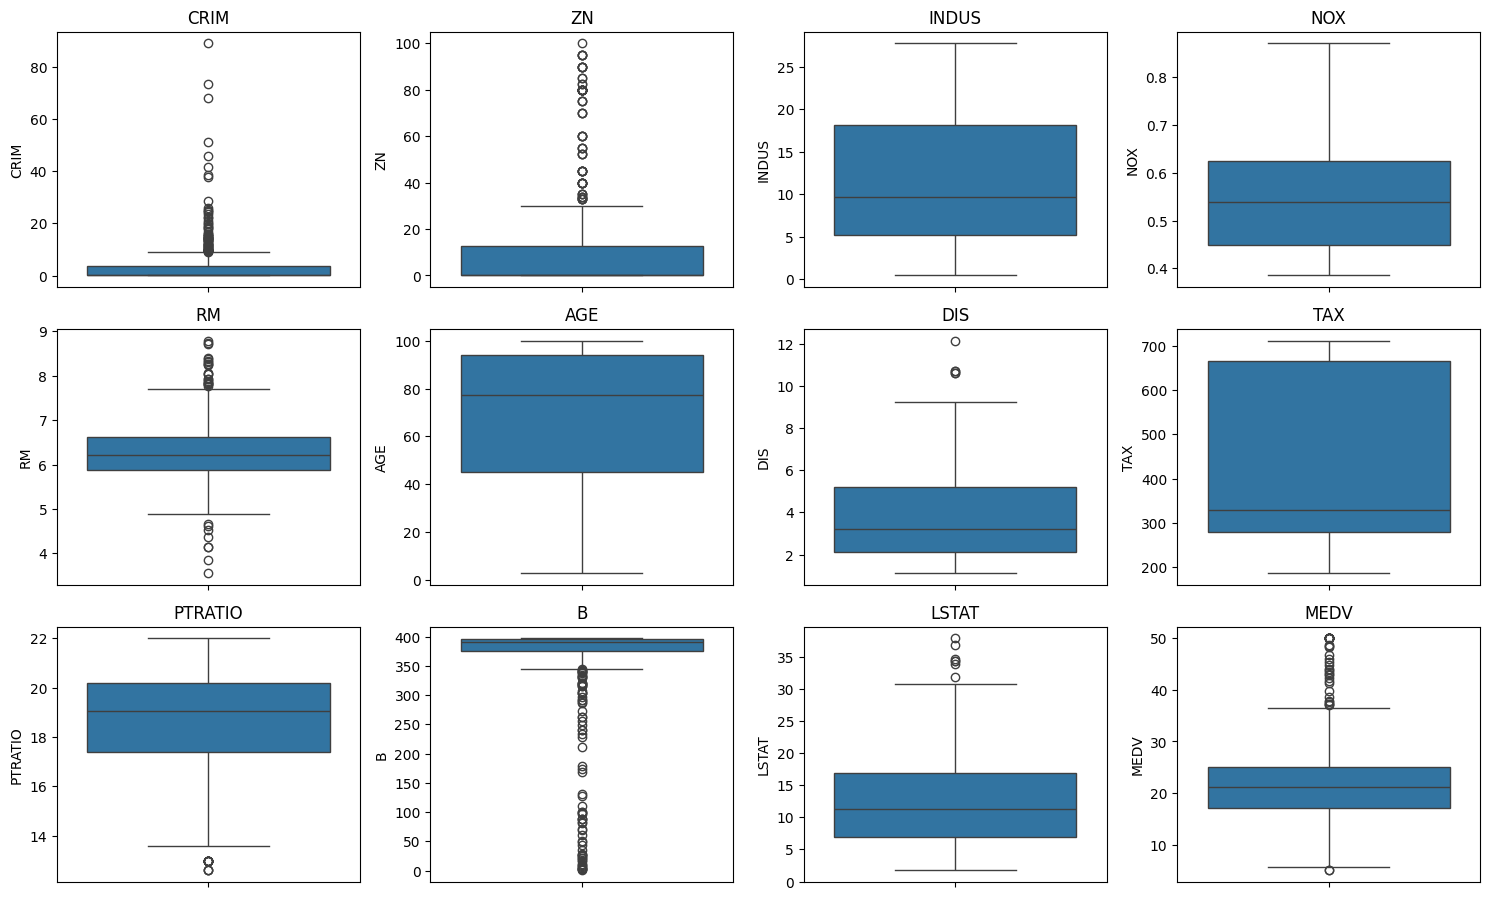

In [47]:
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns
plt.figure(figsize=(15,12))
for i, col in enumerate(numerical_cols, 1):
    plt.subplot(4,4,i)
    sns.boxplot(y=df[col])
    plt.title(col)
plt.tight_layout()
plt.show()

In [48]:
for col in numerical_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    df = df[(df[col] >= lower) & (df[col] <= upper)]

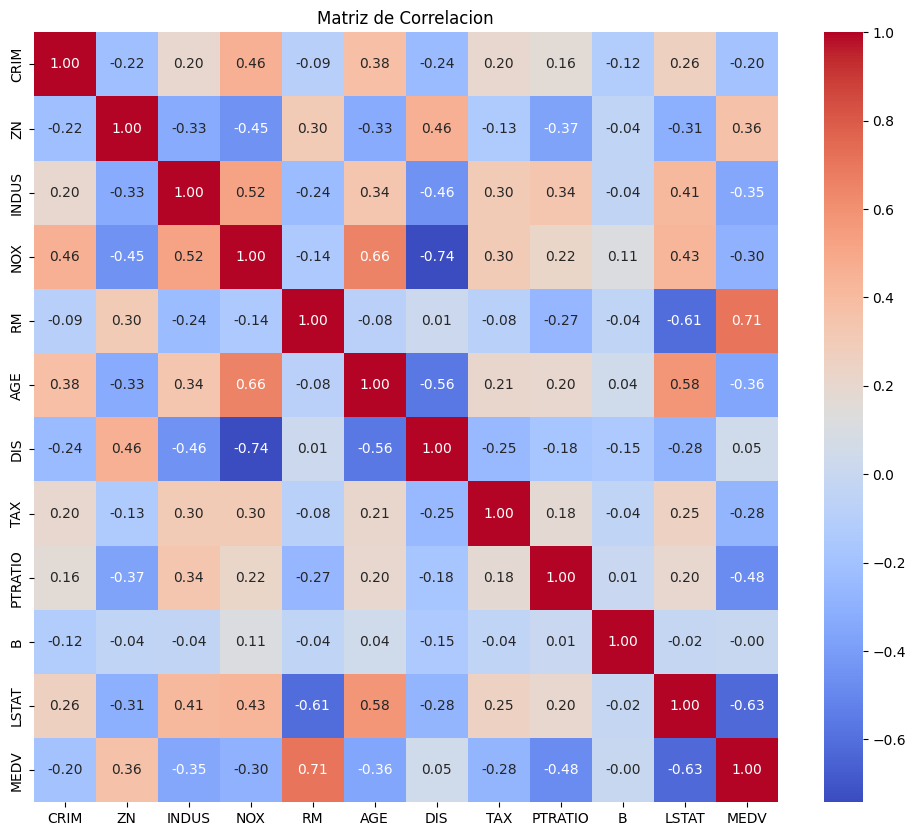

In [49]:
plt.figure(figsize=(12,10))
corr = df[numerical_cols].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Matriz de Correlacion')
plt.show()

**Conclusiones generales EDA**

El analisis exploratorio permitio identificar que el dataset posee buena calidad de datos, sin valores nulos ni registros duplicados. Para el caso de los tipos de datos se encontro que las variables CHAS y RAD fueron identificadas como variables categoricas discretas codificadas numericamente, en este caso se mantivieron en su formato categorico con el fin de conservar su interpretacion original y evitar tratarlas erroneamente como variables continuas en analisis como la matriz de correlacion.

Se detectaron multiples variables con distribuciones asimetricas y presencia de outliers, lo cual podria afectar el rendimiento de algunos modelos sensibles a valores extremos.
Ademas, se observaron relaciones importantes entre variables predictorias y la variable objetivo MEDV, especialmente en RM y LSTAT, que muestran las correlaciones mas fuertes con el precio de las viviendas.

**Preprocesamiento**

In [12]:
features = ['CRIM', 'ZN','INDUS', 'CHAS', 'NOX','RM', 'AGE', 'DIS', 'RAD', 'TAX', 'PTRATIO', 'B', 'LSTAT']
X = df[features]
y = df['MEDV']


In [13]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [52]:
categorical_cols = ['CHAS', 'RAD']
numerical_cols = ['CRIM', 'ZN','INDUS', 'NOX','RM', 'AGE', 'DIS', 'TAX', 'PTRATIO', 'B', 'LSTAT']

preprocesador = ColumnTransformer(transformers=[('num', StandardScaler(), numerical_cols), ('cat', OneHotEncoder(drop='first'), categorical_cols)])

X_train_prep = preprocesador.fit_transform(X_train)
X_test_prep = preprocesador.transform(X_test)

**Modelos de regresion**

In [53]:
linear_model = LinearRegression()
linear_model.fit(X_train_prep, y_train)
y_pred_linear = linear_model.predict(X_test_prep)

In [55]:
knn_model = KNeighborsRegressor(n_neighbors=5)
knn_model.fit(X_train_prep, y_train)
y_pred_knn = knn_model.predict(X_test_prep)

In [56]:
tree_model = DecisionTreeRegressor(max_depth=5, random_state=42)
tree_model.fit(X_train, y_train)
y_pred_tree = tree_model.predict(X_test)

In [57]:
rf_model = RandomForestRegressor(n_estimators=100, max_depth=8, random_state=42)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

**Benchmarking**

In [58]:
results = pd.DataFrame({'Modelo': ['Regresion Lineal', 'KNN', 'Decision Tree', 'Random Forest'], 'MSE': [mean_squared_error(y_test, y_pred_linear), mean_squared_error(y_test, y_pred_knn), mean_squared_error(y_test, y_pred_tree), mean_squared_error(y_test, y_pred_rf)], 'R2': [r2_score (y_test, y_pred_linear), r2_score(y_test, y_pred_knn), r2_score(y_test, y_pred_tree), r2_score(y_test, y_pred_rf)], 'RMSE': [root_mean_squared_error(y_test, y_pred_linear), root_mean_squared_error(y_test, y_pred_knn), root_mean_squared_error(y_test, y_pred_tree), root_mean_squared_error(y_test, y_pred_rf)]})
print(results)

             Modelo        MSE        R2      RMSE
0  Regresion Lineal   5.902378  0.726417  2.429481
1               KNN   6.274332  0.709176  2.504862
2     Decision Tree  10.435004  0.516323  3.230326
3     Random Forest   5.001956  0.768152  2.236505


**Comparacion visual**

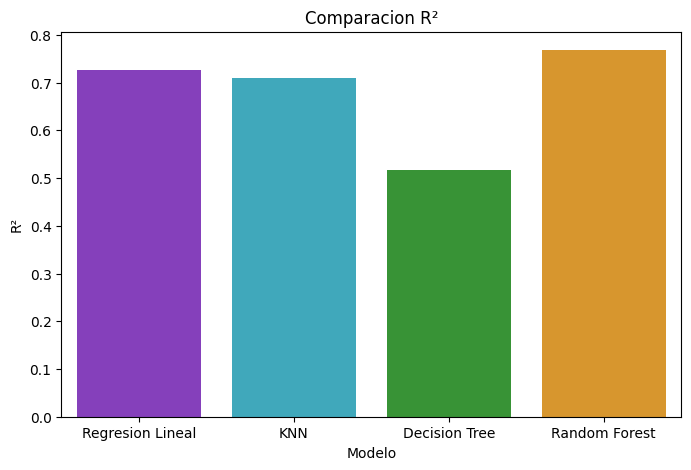

In [59]:
plt.figure(figsize=(8,5))
sns.barplot(data=results, x='Modelo', y='R2', hue='Modelo', palette=['#882BCF','#2BB6CF','#29A326', '#F39C12'], legend=False)
plt.title('Comparacion R²')
plt.ylabel('R²')
plt.xlabel('Modelo')
plt.show()

El modelo RandomForestRegressor suele ofrecer el mejor desempeño en el dataset segun su coeficiente R2, superando a os demas enfoques evaluados.

La regresion lineal y KNN tambien mostrarons resultados competitivos, aunque ligeramente inferiores, mientras que el arbol de decision fue el modelo con menor capacidad predictiva. En general random forest presenta el mejor equilibrio entre precision, estabildad y capacidad de generalizacion.